# ДЗ 5–6. Baseline: прогноз дефолта (Home Credit)

## Описание кейса

**Продукт:** AI-система оценки финансового риска клиента банка.

**Задача:** по данным заявки предсказать дефолт по кредиту (`TARGET = 1` — клиент не смог платить вовремя).

**Данные (архив):** [Яндекс.Диск — data.rar](https://disk.yandex.ru/client/disk?idApp=client&dialog=slider&idDialog=%2Fdisk%2Fdata.rar) — распаковать в папку data/ в корне репозитория.

**Источник:** [Kaggle Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk) — анкета заявки + связанные таблицы (bureau, installments).

**Структура ноутбука (соответствие ДЗ):**

| Раздел | Баллы | Содержание |
|--------|-------|------------|
| 1. Загрузка и очистка | 4 | сырые данные → правила очистки → `df_clean` |
| 2. Анализ данных | 5 | TARGET, пропуски, связь с дефолтом, графики |
| 3. Моделирование | 7 | LR + RF (простые) + LightGBM+Optuna (усложнённая) |
| 4. Метрики | 4 | AUC-ROC, PR-AUC, сводка, анализ результатов |


In [ ]:
from pathlib import Path
import sys
import warnings
import logging

warnings.filterwarnings("ignore")
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
import lightgbm as lgb
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.data_prep import clean_application, load_train_datasets

DATA_DIR = ROOT / "data"
TRAIN_PATH = DATA_DIR / "application_train.csv"
RANDOM_STATE = 42
N_SPLITS = 5

def pct(x: float) -> str:
    return f"{100.0 * x:.2f}%"


---
# Часть 1. Загрузка и очистка данных (4 балла)

**Цель:** привести `application_train` к виду, пригодному для модели.

**Правила очистки:**
1. Удалить дубликаты по `SK_ID_CURR`
2. `DAYS_EMPLOYED == 365243` → `NaN` (код пропуска)
3. Удалить колонки с ≥65% пропусков (блок жилья)
4. Добавить флаги пропусков для `EXT_SOURCE_1/2/3`


In [2]:
df_raw = pd.read_csv(TRAIN_PATH)
df_raw["SK_ID_CURR"] = df_raw["SK_ID_CURR"].astype("int64")

df_clean = clean_application(df_raw)

audit = pd.DataFrame({
    "показатель": ["строк", "колонок", "дубликаты SK_ID_CURR", "DAYS_EMPLOYED=365243"],
    "до": [len(df_raw), df_raw.shape[1], int(df_raw["SK_ID_CURR"].duplicated().sum()), int((df_raw["DAYS_EMPLOYED"] == 365243).sum())],
    "после": [len(df_clean), df_clean.shape[1], int(df_clean["SK_ID_CURR"].duplicated().sum()), int((df_clean["DAYS_EMPLOYED"] == 365243).sum())],
})
display(audit)
df_clean.head(2)


,показатель,до,после
0,строк,307511,307511
1,колонок,122,108
2,дубликаты SK_ID_CURR,0,0
3,DAYS_EMPLOYED=365243,55374,0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1


**Вывод по очистке:** строки сохранены (1 заявка = 1 строка), убран пустой блок жилья, аномалия стажа исправлена. Доля `TARGET` не изменилась.

---
# Часть 2. Анализ данных (5 баллов)

**Цель:** понять распределение целевой переменной, качество признаков и связь с дефолтом.


,класс,количество,доля
0,0 — без дефолта,282686,91.93%
1,1 — дефолт,24825,8.07%


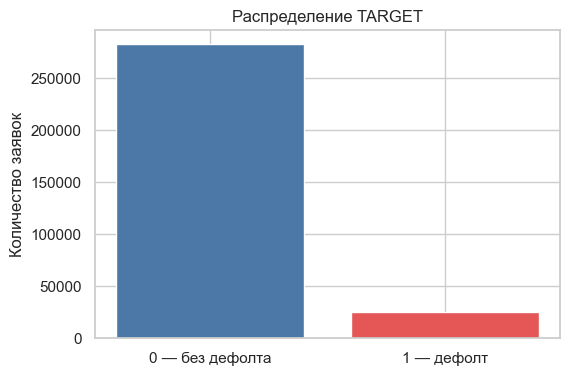

In [3]:
counts = df_clean["TARGET"].value_counts().sort_index()
target_summary = pd.DataFrame({
    "класс": ["0 — без дефолта", "1 — дефолт"],
    "количество": counts.values,
    "доля": [pct(v / len(df_clean)) for v in counts.values],
})
display(target_summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_summary["класс"], target_summary["количество"], color=["#4c78a8", "#e45756"])
ax.set_title("Распределение TARGET")
ax.set_ylabel("Количество заявок")
plt.show()


,"доля пропусков, %"
LANDAREA_MODE,59.38
LANDAREA_MEDI,59.38
LANDAREA_AVG,59.38
BASEMENTAREA_AVG,58.52
BASEMENTAREA_MODE,58.52
BASEMENTAREA_MEDI,58.52
EXT_SOURCE_1,56.38
NONLIVINGAREA_MEDI,55.18
NONLIVINGAREA_AVG,55.18
NONLIVINGAREA_MODE,55.18


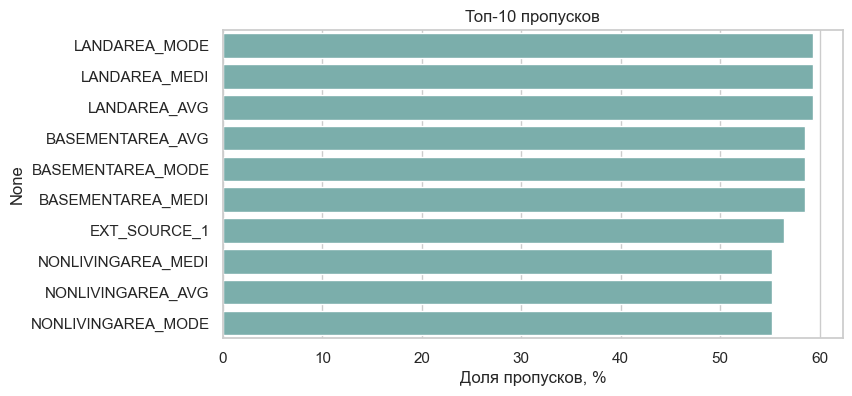

In [4]:
miss = (df_clean.isna().mean().sort_values(ascending=False).head(10) * 100).round(2)
display(miss.to_frame("доля пропусков, %"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=miss.values, y=miss.index, ax=ax, color="#72b7b2")
ax.set_xlabel("Доля пропусков, %")
ax.set_title("Топ-10 пропусков")
plt.show()


,corr с TARGET
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
DAYS_BIRTH,0.0782
DAYS_EMPLOYED,0.0750
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552
DAYS_ID_PUBLISH,0.0515
REG_CITY_NOT_WORK_CITY,0.0510


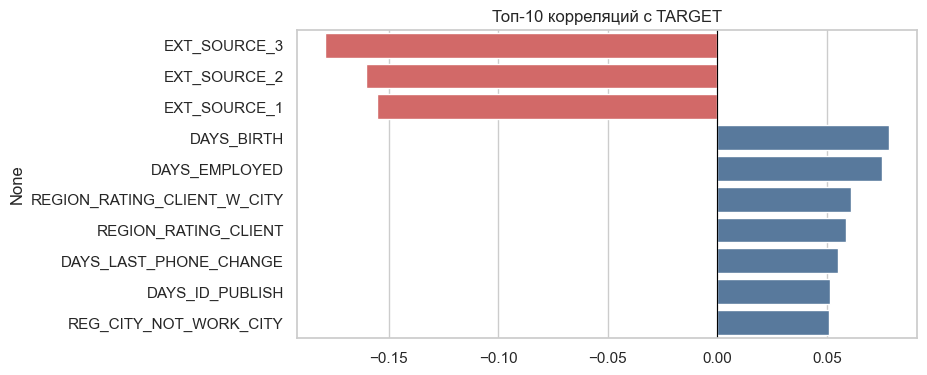

In [5]:
num = df_clean.select_dtypes(include=[np.number])
corr = num.corr(numeric_only=True)["TARGET"].drop("TARGET", errors="ignore")
corr = corr.reindex(corr.abs().sort_values(ascending=False).head(10).index)
display(corr.round(4).to_frame("corr с TARGET"))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e45756" if v < 0 else "#4c78a8" for v in corr.values]
sns.barplot(x=corr.values, y=corr.index, ax=ax, palette=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Топ-10 корреляций с TARGET")
plt.show()


**Выводы EDA:**
- Сильный **дисбаланс классов** (~8% дефолтов) → stratified CV, метрики PR-AUC
- Сильнее всего связаны **EXT_SOURCE_1/2/3** и **DAYS_BIRTH**
- Пропуски остались в EXT_SOURCE и DAYS_EMPLOYED → impute на этапе модели


---
# Часть 3. Моделирование (7 баллов)

| Модель | Тип | Признаки |
|--------|-----|----------|
| Logistic Regression | простая (baseline) | анкета, числовые |
| Random Forest | простая | анкета, числовые |
| LightGBM + Optuna | усложнённая | анкета + bureau + installments + тюнинг |

**Валидация:** Stratified K-Fold, k=5.


In [6]:
df_base, df_full = load_train_datasets(DATA_DIR)

def split_xy(df, numeric_only=False):
    y = df["TARGET"].astype(int)
    X = df.drop(columns=["TARGET", "SK_ID_CURR"])
    if numeric_only:
        X = X.select_dtypes(include=[np.number])
    return X, y

def ci95(values):
    arr = np.asarray(values, dtype=float)
    mean = float(arr.mean())
    if len(arr) < 2:
        return mean, mean, mean
    h = stats.sem(arr) * stats.t.ppf(0.975, len(arr) - 1)
    return mean, mean - h, mean + h

def eval_cv(model, X, y, n_splits=N_SPLITS):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs, prs = [], []
    for tr, va in skf.split(X, y):
        model.fit(X.iloc[tr], y.iloc[tr])
        p = model.predict_proba(X.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y.iloc[va], p))
        prs.append(average_precision_score(y.iloc[va], p))
    am, al, ah = ci95(aucs)
    pm, pl, ph = ci95(prs)
    return {"auc_mean": am, "auc_ci": (al, ah), "pr_mean": pm, "pr_ci": (pl, ph), "auc_folds": aucs, "pr_folds": prs}

lr_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced", random_state=RANDOM_STATE)),
])
rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=50,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
])

X_num, y = split_xy(df_base, numeric_only=True)
lr_res = eval_cv(lr_pipe, X_num, y)
rf_res = eval_cv(rf_pipe, X_num, y)


In [7]:
X_full, y_full = split_xy(df_full)
for c in X_full.select_dtypes(include=["object"]).columns:
    X_full[c] = X_full[c].astype("category")

def lgbm_cv_auc(params, X_tr, y_tr, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in skf.split(X_tr, y_tr):
        m = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X_tr.iloc[tr], y_tr.iloc[tr], eval_set=[(X_tr.iloc[va], y_tr.iloc[va])],
              eval_metric="auc", callbacks=[lgb.early_stopping(50, verbose=False)])
        scores.append(roc_auc_score(y_tr.iloc[va], m.predict_proba(X_tr.iloc[va])[:, 1]))
    return float(np.mean(scores))

def tune_lgbm(X_tr, y_tr, n_trials=15):
    def objective(trial):
        params = {
            "objective": "binary",
            "n_estimators": trial.suggest_int("n_estimators", 200, 800),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 16, 64),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "class_weight": "balanced",
        }
        return lgbm_cv_auc(params, X_tr, y_tr)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def eval_lgbm(X, y, best_params):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    aucs, prs = [], []
    for tr, va in skf.split(X, y):
        m = lgb.LGBMClassifier(**best_params, objective="binary", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y.iloc[va], p))
        prs.append(average_precision_score(y.iloc[va], p))
    am, al, ah = ci95(aucs)
    pm, pl, ph = ci95(prs)
    return {"auc_mean": am, "auc_ci": (al, ah), "pr_mean": pm, "pr_ci": (pl, ph), "auc_folds": aucs, "pr_folds": prs}

tune_idx = y_full.sample(frac=0.8, random_state=RANDOM_STATE, replace=False).index
best_params = tune_lgbm(X_full.loc[tune_idx], y_full.loc[tune_idx], n_trials=15)
lgbm_res = eval_lgbm(X_full, y_full, best_params)


---
# Часть 4. Метрики качества и анализ результатов (4 балла)

**Метрики (≥2):**
- **AUC-ROC** — качество ранжирования заявок по риску
- **PR-AUC** — качество при дисбалансе классов (~8% дефолтов)

**Совокупная метрика:** среднее нормализованных AUC и PR-AUC по фолдам — `combined_score = (AUC + PR-AUC) / 2`

**Анализ:** сравнение с baseline (LR), прирост AUC, 95% доверительные интервалы.


In [8]:
def fmt_ci(mean, ci):
    return f"{mean:.4f} [{ci[0]:.4f}; {ci[1]:.4f}]"

results = []
for name, res in [("Logistic Regression", lr_res), ("Random Forest", rf_res), ("LightGBM + Optuna", lgbm_res)]:
    combined = (res["auc_mean"] + res["pr_mean"]) / 2
    results.append({
        "Модель": name,
        "AUC-ROC": fmt_ci(res["auc_mean"], res["auc_ci"]),
        "PR-AUC": fmt_ci(res["pr_mean"], res["pr_ci"]),
        "combined_score": round(combined, 4),
    })

summary = pd.DataFrame(results).sort_values("combined_score", ascending=False)
display(summary)

delta = np.array(lgbm_res["auc_folds"]) - np.array(lr_res["auc_folds"])
d_mean, d_lo, d_hi = ci95(delta.tolist())

best = summary.iloc[0]
print("=== Анализ результатов ===")
print(f"Лучшая модель: {best['Модель']} (combined_score = {best['combined_score']})")
print(f"Baseline LR:  AUC = {lr_res['auc_mean']:.4f}, PR-AUC = {lr_res['pr_mean']:.4f}")
print(f"Лучшая LGBM:  AUC = {lgbm_res['auc_mean']:.4f}, PR-AUC = {lgbm_res['pr_mean']:.4f}")
print(f"Прирост AUC (LGBM − LR): {d_mean:.4f} [{d_lo:.4f}; {d_hi:.4f}]")
if d_lo > 0:
    print("Гипотеза подтверждена: bureau + installments улучшают скоринг (CI прироста не включает 0)")
else:
    print("Устойчивый прирост не подтверждён")


,Модель,AUC-ROC,PR-AUC,combined_score
2,LightGBM + Optuna,0.7694 [0.7654; 0.7733],0.2576 [0.2482; 0.2670],0.5135
0,Logistic Regression,0.7403 [0.7335; 0.7471],0.2184 [0.2107; 0.2260],0.4793
1,Random Forest,0.7328 [0.7273; 0.7383],0.2100 [0.2049; 0.2150],0.4714


=== Анализ результатов ===
Лучшая модель: LightGBM + Optuna (combined_score = 0.5135)
Baseline LR:  AUC = 0.7403, PR-AUC = 0.2184
Лучшая LGBM:  AUC = 0.7694, PR-AUC = 0.2576
Прирост AUC (LGBM − LR): 0.0290 [0.0259; 0.0321]
Гипотеза подтверждена: bureau + installments улучшают скоринг (CI прироста не включает 0)


## Итоговые выводы

1. **Данные:** очищены без потери строк; дисбаланс TARGET ~8%.
2. **EDA:** ключевые предикторы — внешние скоринги EXT_SOURCE; нужен stratified split.
3. **Модели:** 2 простые (LR, RF) + 1 усложнённая (LightGBM + Optuna).
4. **Метрики:** AUC-ROC и PR-AUC; лучшая — LightGBM + Optuna по `combined_score`.
5. **Рекомендация:** использовать LGBM для MVP; LR — как baseline для контроля качества.
